In [6]:
# library imports
import tensorflow as tf
devices = tf.config.list_physical_devices()
print("Devices found:", devices)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("Success! GPU is active.")
    # This line tells TF to use the GPU specifically
    tf.config.set_visible_devices(gpu_devices[0], 'GPU')
else:
    print("GPU still not found. You might be running an Intel version of Python.")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from keras.models import Sequential
# from keras.layers import Dense, ConV1D, Flatten, MaxPooling2D, Input, Bidirectional, LSTM, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import mlflow
import mlflow.keras
sns.set(style="darkgrid")

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPU still not found. You might be running an Intel version of Python.


In [7]:
# data aquisition
df = pd.read_csv("/Users/faizshaikh/Documents/machine_learning/detect_dataset.xls", sep=",", index_col=False)
df.drop(columns=["Unnamed: 7", "Unnamed: 8"], inplace=True)
print(df.head())

   Output (S)          Ia        Ib          Ic        Va        Vb        Vc
0           0 -170.472196  9.219613  161.252583  0.054490 -0.659921  0.605431
1           0 -122.235754  6.168667  116.067087  0.102000 -0.628612  0.526202
2           0  -90.161474  3.813632   86.347841  0.141026 -0.605277  0.464251
3           0  -79.904916  2.398803   77.506112  0.156272 -0.602235  0.445963
4           0  -63.885255  0.590667   63.294587  0.180451 -0.591501  0.411050


In [8]:
print(df.describe())

         Output (S)            Ia            Ib            Ic            Va  \
count  12001.000000  12001.000000  12001.000000  12001.000000  12001.000000   
mean       0.457962      6.709369    -26.557793     22.353043      0.010517   
std        0.498250    377.158470    357.458613    302.052809      0.346221   
min        0.000000   -883.542316   -900.526951   -883.357762     -0.620748   
25%        0.000000    -64.348986    -51.421937    -54.562257     -0.237610   
50%        0.000000     -3.239788      4.711283     -0.399419      0.002465   
75%        1.000000     53.823453     69.637787     45.274542      0.285078   
max        1.000000    885.738571    889.868884    901.274261      0.609864   

                 Vb            Vc  
count  12001.000000  12001.000000  
mean      -0.015498      0.004980  
std        0.357644      0.349272  
min       -0.659921     -0.612709  
25%       -0.313721     -0.278951  
50%       -0.007192      0.008381  
75%        0.248681      0.289681  


In [9]:
print(df.dtypes)

Output (S)      int64
Ia            float64
Ib            float64
Ic            float64
Va            float64
Vb            float64
Vc            float64
dtype: object


In [10]:
df.isna().sum()

Output (S)    0
Ia            0
Ib            0
Ic            0
Va            0
Vb            0
Vc            0
dtype: int64

In [11]:
df["Output (S)"].value_counts()

Output (S)
0    6505
1    5496
Name: count, dtype: int64

<Axes: xlabel='Output (S)', ylabel='count'>

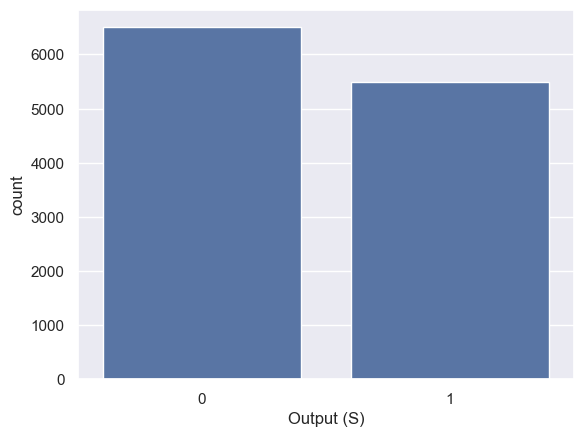

In [12]:
sns.countplot(x=df["Output (S)"])

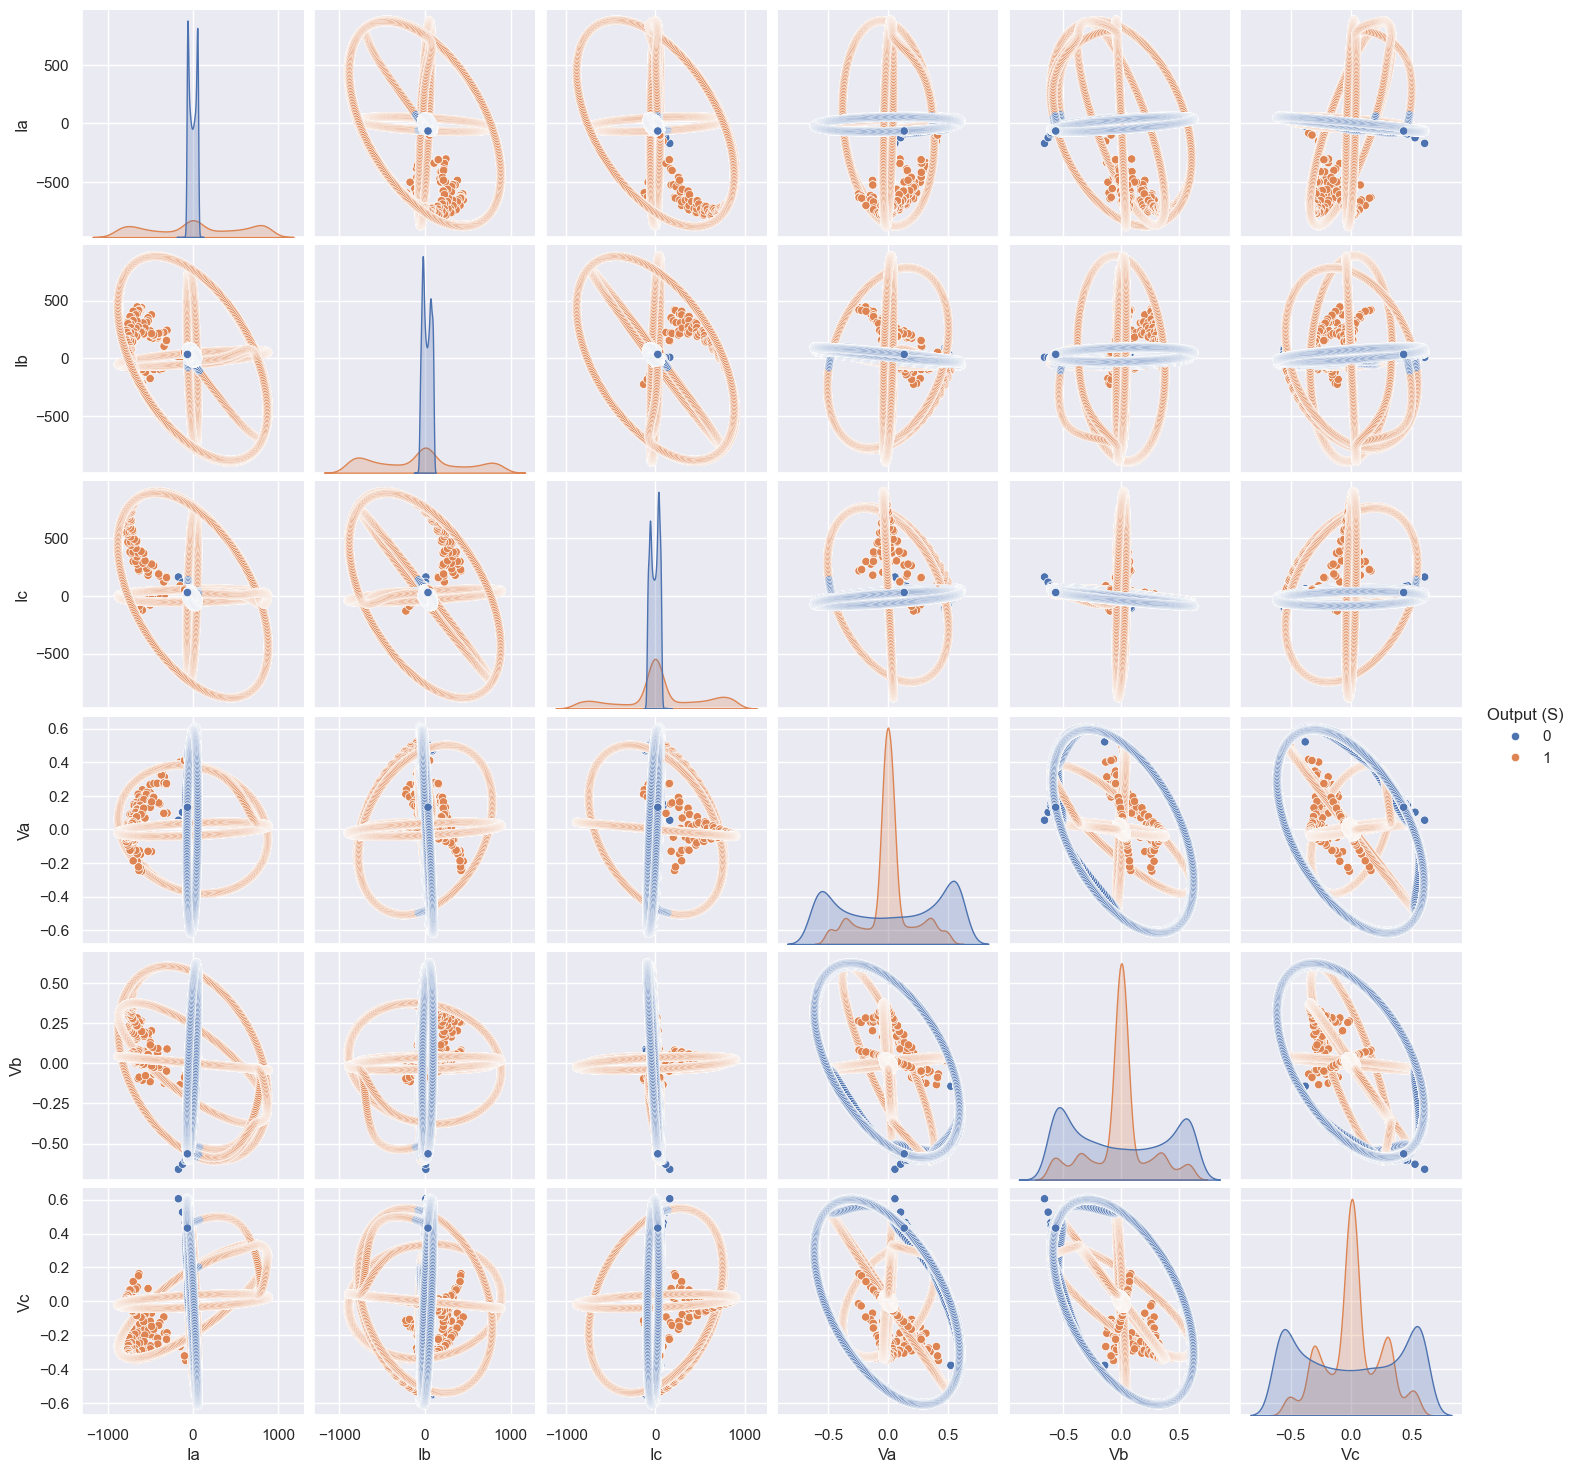

In [13]:
sns.pairplot(df, hue="Output (S)")

Text(0.5, 1.0, 'Spearman')

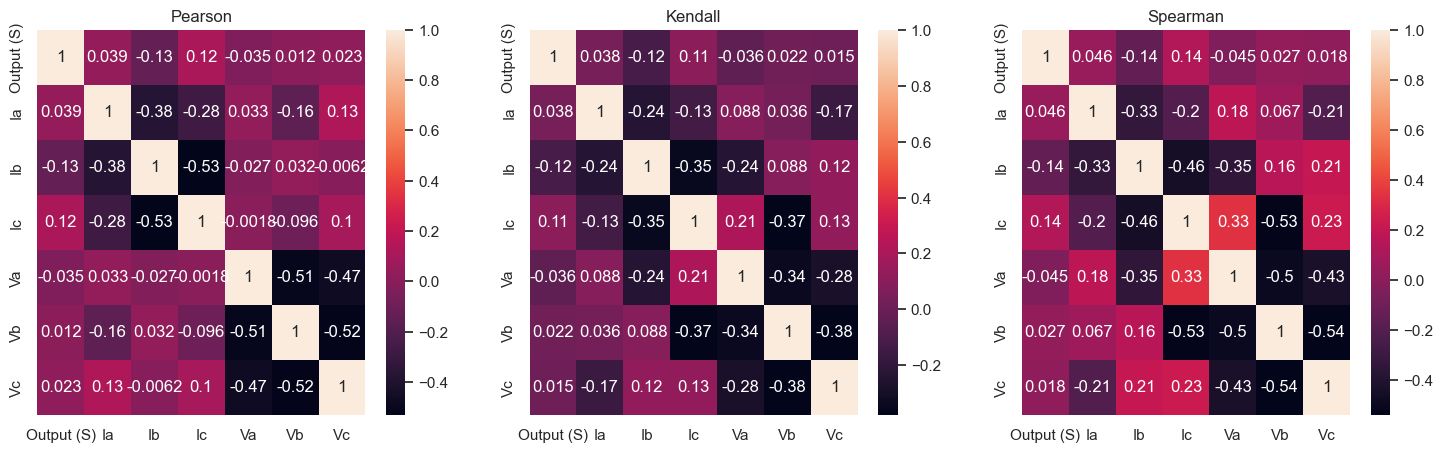

In [14]:
# correlation plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot 1: Pearson (Linear correlation)
sns.heatmap(df.corr(method="pearson"), annot=True, ax=axes[0])
axes[0].set_title("Pearson")

# plot 2: Kendall (Ordinal association)
sns.heatmap(df.corr(method="kendall"), annot=True, ax=axes[1])
axes[1].set_title("Kendall")

# plot 3: Spearman (Rank correlation)
sns.heatmap(df.corr(method="spearman"), annot=True, ax=axes[2])
axes[2].set_title("Spearman")

In [15]:
# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(df, df["Output (S)"], test_size=0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)

(9000, 7) (1500, 7) (1501, 7)
(9000,) (1500,) (1501,)


In [16]:
# developing models
model = tf.keras.Sequential()
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(8), name="Bidirectional_LSTM_1", input_shape=(X_train.shape[1], 1)))
model.add(tf.keras.layers.Dropout(0.2, name="Dropout_1"))
model.add(tf.keras.layers.Dense(8, activation="sigmoid", name="Dense_1"))
model.add(tf.keras.layers.Dense(1, activation="sigmoid", name="Output_Layer"))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
print(model.summary())

/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Bidirectional_LSTM_1            │ (None, 16)             │           640 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [17]:
history = model.fit(X_train, y_train, epochs=50, verbose=1, validation_data=(X_val, y_val))

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6747 - loss: 0.6285 - val_accuracy: 0.9087 - val_loss: 0.4359
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9767 - loss: 0.1967 - val_accuracy: 0.9920 - val_loss: 0.0911
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9930 - loss: 0.0725 - val_accuracy: 0.9980 - val_loss: 0.0439
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9977 - loss: 0.0382 - val_accuracy: 0.9987 - val_loss: 0.0276
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9992 - loss: 0.0238 - val_accuracy: 0.9993 - val_loss: 0.0187
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9993 - loss: 0.0175 - val_accuracy: 1.0000 - val_loss: 0.0122
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9989 - loss: 0.0152 - val_accuracy: 0.9973 - val_loss: 0.0158
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9970 - loss: 0.0181 - val_accuracy: 0.

In [18]:
# classification report
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(y_pred.shape)
print(classification_report(y_test, y_pred))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
(1501, 1)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       1.00      1.00      1.00       703

    accuracy                           1.00      1501
   macro avg       1.00      1.00      1.00      1501
weighted avg       1.00      1.00      1.00      1501



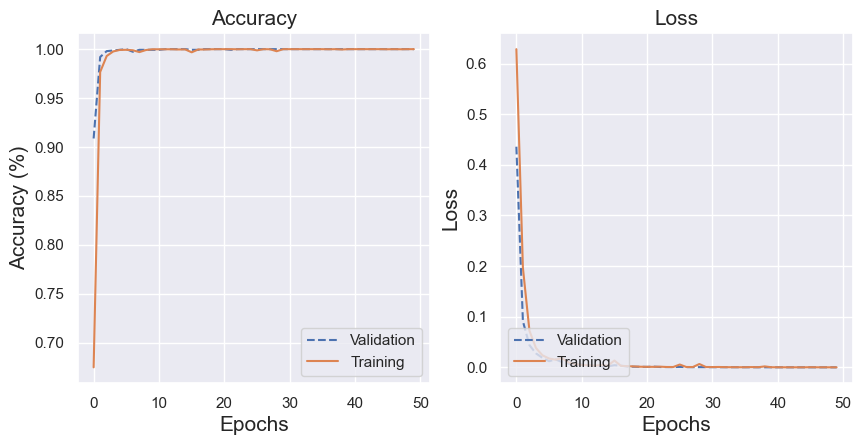

In [19]:
fig = plt.figure(figsize=(10, 10))

# summarize history for accuracy
plt.subplot(2, 2, 1)

plt.title("Accuracy", fontsize=15)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Accuracy (%)", fontsize=15)
plt.plot(history.history["val_accuracy"],
label='Validation Accuracy', linestyle='dashed')
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.legend(["Validation", "Training"], loc="lower right")

plt.subplot(2, 2, 2)
plt.title("Loss", fontsize=15)
plt.xlabel("Epochs", fontsize=15)
plt.ylabel("Loss", fontsize=15)
plt.plot(history.history["val_loss"], label='Validation loss', linestyle='dashed')
plt.plot(history.history["loss"], label='Training loss')
plt.legend(["Validation", "Training"], loc="lower left")



<Axes: >

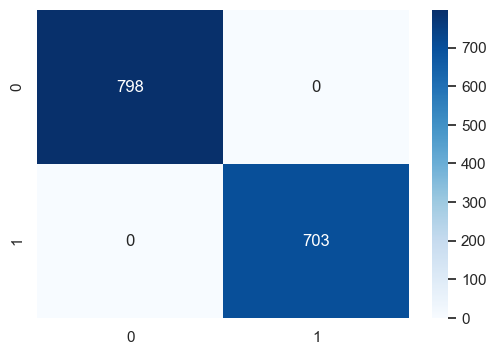

In [20]:
# confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cf_matrix, annot=True, fmt="d", cmap="Blues")